### Import and initial data exploration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# Load data
df = pd.read_csv("Dataset.csv")

# Basic sanity cleanup
df.columns = df.columns.str.strip()
if "Country" in df.columns:
    df["Country"] = df["Country"].astype(str).str.strip()

display(df.head())
print("Shape:", df.shape)

print("\n--- INFO ---")
df.info()

print("\n--- Missingness (top 25) ---")
display(df.isna().mean().sort_values(ascending=False).head(25))


,Country,Year,Gender,Life Expectancy,Infant Mortality Rate,Low CI Value Infant Mortality Rate,High CI Value Infant Mortality Rate,Under 5 Mortality Rate,Low CI Value Under 5 Mortality Rate,High CI Value Under 5 Mortality Rate,% Death Cardiovascular,Low CI Value % Death Cardiovascular,High CI Value % Death Cardiovascular,Suicides Rate,Alcohol Abuse,Air Pollution Death Rate Stroke,Low CI Value Air Pollution Death Rate Stroke,High CI Value Air Pollution Death Rate Stroke,Air Pollution Death Rate Stroke Age Standarized,Low CI Value Air Pollution Death Rate Stroke Age Standarized,High CI Value Air Pollution Death Rate Stroke Age Standarized,Air Pollution Death Rate Ischaemic Heart Disease,Low CI Value Air Pollution Death Rate Ischaemic Heart Disease,High CI Value Air Pollution Death Rate Ischaemic Heart Disease,Air Pollution Death Rate Ischaemic Heart Disease Age Standarized,Low CI Value Air Pollution Death Rate Ischaemic Heart Disease Age Standarized,High CI Value Air Pollution Death Rate Ischaemic Heart Disease Age Standarized,Air Pollution Death Rate Lower Respiratory Infections,Low CI Value Air Pollution Death Rate Lower Respiratory Infections,High CI Value Air Pollution Death Rate Lower Respiratory Infections,Air Pollution Death Rate Lower Respiratory Infections Age Standarized,Low CI Value Air Pollution Death Rate Lower Respiratory Infections Age Standarized,High CI Value Air Pollution Death Rate Lower Respiratory Infections Age Standarized,Air Pollution Death Rate Chronic Obstructive Pulmonary Disease,Low CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease,High CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease,Air Pollution Death Rate Chronic Obstructive Pulmonary Disease Age Standarized,Low CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease Age Standarized,High CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease Age Standarized,Air Pollution Death Rate Total,Low CI Value Air Pollution Death Rate Total,High CI Value Air Pollution Death Rate Total,Air Pollution Death Rate Total Age Standarized,Low CI Value Air Pollution Death Rate Total Age Standarized,High CI Value Air Pollution Death Rate Total Age Standarized,Air Pollution Death Rate Trachea Bronchus Lung Cancers,Low CI Value Air Pollution Death Rate Trachea Bronchus Lung Cancers,High CI Value Air Pollution Death Rate Trachea Bronchus Lung Cancers,Air Pollution Death Rate Trachea Bronchus Lung Cancers Age Standarized,Low CI Value Air Pollution Death Rate Trachea Bronchus Lung Cancers Age Standarized,High CI Value Air Pollution Death Rate Trachea Bronchus Lung Cancers Age Standarized,Unsafe Wash Mortality Rate,Poisoning Mortality Rate,Tobacco Prevalence,% Population Aged 0-14,% Population Aged 15-64,% Population Aged 65+,% Population Aged 65-69,% Population Aged 70-74,% Population Aged 75-79,% Population Aged 80+,Maternal Mortality Ratio,Low CI Value Maternal Mortality Ratio,High CI Value Maternal Mortality Ratio,% of Births Attended By Skilled Personal,Neonatal Mortality Rate,Low CI Value Neonatal Mortality Rate,High CI Value Neonatal Mortality Rate,Incidence of Malaria,Incidence of Tuberculosis,Low CI Value Incidence of Tuberculosis,High CI Value Incidence of Tuberculosis,Hepatitis B Surface Antigen,Low CI Value Hepatitis B Surface Antigen,High CI Value Hepatitis B Surface Antigen,Intervention Against NTDs,Road Traffic Deaths,Reproductive Age Women,Adolescent Birth Rate,Universal Heath Care Coverage,Population 10 Percentage SDG Total,Population 10 Percentage SDG Urban,Population 10 Percentage SDG Rural,Population 25 Percentage SDG Total,Population 25 Percentage SDG Urban,Population 25 Percentage SDG Rural,Doctors,Nurses and Midwifes,Dentists,Pharmacists,Basic Drinking Water Services,Basic Sanization Services Total,Basic Sanization Services Urban,Basic Sanization Services Rural,Safely Sanitation Total,Safely Sanitation Urban,Safely Sanitation Rural,Basic Hand Washing Total,Basic Hand Washing

Shape: (22050, 150)

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22050 entries, 0 to 22049
Columns: 150 entries, Country to Diet Calories Carbohydrates
dtypes: float64(147), int64(1), object(2)
memory usage: 25.2+ MB

--- Missingness (top 25) ---


,0
Reproductive Age Women,0.984490
High CI Value Air Pollution Death Rate Stroke,0.975646
High CI Value Air Pollution Death Rate Stroke Age Standarized,0.975646
Low CI Value Air Pollution Death Rate Stroke Age Standarized,0.975646
Air Pollution Death Rate Ischaemic Heart Disease,0.975646
Low CI Value Air Pollution Death Rate Stroke,0.975646
Air Pollution Death Rate Stroke,0.975646
Air Pollution Death Rate Chronic Obstructive Pulmonary Disease Age Standarized,0.975646
High CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease,0.975646
Low CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease,0.975646


### Checking uniquness, dublication, number of countries and etc.

In [2]:
import pandas as pd
import numpy as np

# --- Basic shape + columns ---
print("Rows, Columns:", df.shape)
print("\nColumn preview:")
print(df.columns.tolist())

# --- Type summary ---
type_summary = (
    df.dtypes.astype(str)
    .value_counts()
    .rename_axis("dtype")
    .reset_index(name="count")
)
print("\nDtype counts:")
print(type_summary.to_string(index=False))

# --- Country + Year sanity checks ---
if "Country" in df.columns:
    print("\nUnique countries:", df["Country"].nunique())
    print("First 20 countries alphabetically:", sorted(df["Country"].dropna().unique())[:20])

if "Year" in df.columns:
    # Coerce Year to numeric if it's messy
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    print("\nYear range:", int(df["Year"].min()), "to", int(df["Year"].max()))
    print("Unique years:", df["Year"].nunique())

# --- Duplicates check (Country-Year duplicates are common issues) ---
if {"Country", "Year"}.issubset(df.columns):
    dup_ct = df.duplicated(subset=["Country", "Year","Gender"]).sum()
    print("\nDuplicate Country-Year-Gender rows:", dup_ct)
    if dup_ct > 0:
        display(df[df.duplicated(subset=["Country", "Year"], keep=False)].sort_values(["Country","Year"]).head(20))


Rows, Columns: (22050, 150)

Column preview:
['Country', 'Year', 'Gender', 'Life Expectancy', 'Infant Mortality Rate', 'Low CI Value Infant Mortality Rate', 'High CI Value Infant Mortality Rate', 'Under 5 Mortality Rate', 'Low CI Value Under 5 Mortality Rate', 'High CI Value Under 5 Mortality Rate', '% Death Cardiovascular', 'Low CI Value % Death Cardiovascular', 'High CI Value % Death Cardiovascular', 'Suicides Rate', 'Alcohol Abuse', 'Air Pollution Death Rate Stroke', 'Low CI Value Air Pollution Death Rate Stroke', 'High CI Value Air Pollution Death Rate Stroke', 'Air Pollution Death Rate Stroke Age Standarized', 'Low CI Value Air Pollution Death Rate Stroke Age Standarized', 'High CI Value Air Pollution Death Rate Stroke Age Standarized', 'Air Pollution Death Rate Ischaemic Heart Disease', 'Low CI Value Air Pollution Death Rate Ischaemic Heart Disease', 'High CI Value Air Pollution Death Rate Ischaemic Heart Disease', 'Air Pollution Death Rate Ischaemic Heart Disease Age Standarized

### We saw above there are too much missing values, it is good to check it

In [3]:
# --- Missingness per column ---
missing_cols = (
    df.isna().mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_%")
    .to_frame()
)
missing_cols["non_missing_count"] = df.notna().sum()
missing_cols["dtype"] = df.dtypes.astype(str)

print("\nTop 25 columns by missingness:")
display(missing_cols.head(25))

print("\nBottom 25 columns by missingness (best coverage):")
display(missing_cols.tail(25))

# --- Missingness per row (useful to see if some rows are mostly empty) ---
row_missing_pct = df.isna().mean(axis=1).mul(100)
print("\nRow missingness % summary:")
print(row_missing_pct.describe().to_string())

# --- Missingness by country (average % missing across ALL columns) ---
if "Country" in df.columns:
    missing_by_country = (
        df.groupby("Country")
          .apply(lambda g: g.isna().mean().mean() * 100)  # mean across columns then rows
          .sort_values(ascending=False)
          .rename("avg_missing_%")
          .to_frame()
    )
    print("\nCountries with worst overall missingness (top 20):")
    display(missing_by_country.head(20))

    print("\nCountries with best overall coverage (top 20):")
    display(missing_by_country.tail(20))



Top 25 columns by missingness:


,missing_%,non_missing_count,dtype
Reproductive Age Women,98.448980,342,float64
High CI Value Air Pollution Death Rate Stroke,97.564626,537,float64
High CI Value Air Pollution Death Rate Stroke Age Standarized,97.564626,537,float64
Low CI Value Air Pollution Death Rate Stroke Age Standarized,97.564626,537,float64
Air Pollution Death Rate Ischaemic Heart Disease,97.564626,537,float64
Low CI Value Air Pollution Death Rate Stroke,97.564626,537,float64
Air Pollution Death Rate Stroke,97.564626,537,float64
Air Pollution Death Rate Chronic Obstructive Pulmonary Disease Age Standarized,97.564626,537,float64
High CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease,97.564626,537,float64
Low CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease,97.564626,537,float64



Bottom 25 columns by missingness (best coverage):


,missing_%,non_missing_count,dtype
Income per Capita,36.575964,13985,float64
Infant Mortality Rate,34.435374,14457,float64
Low CI Value Infant Mortality Rate,34.435374,14457,float64
Under 5 Mortality Rate,34.435374,14457,float64
High CI Value Infant Mortality Rate,34.435374,14457,float64
High CI Value Under 5 Mortality Rate,34.435374,14457,float64
Low CI Value Under 5 Mortality Rate,34.435374,14457,float64
Conflict and Terrorism Deaths,30.816327,15255,float64
GNI per Capita,30.589569,15305,float64
Vegetable Consumption,29.750567,15490,float64



Row missingness % summary:
count    22050.000000
mean        65.291308
std         19.220293
min         28.000000
25%         48.000000
50%         61.333333
75%         84.000000
max         97.333333

Countries with worst overall missingness (top 20):


/tmp/ipython-input-3169667897.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.isna().mean().mean() * 100)  # mean across columns then rows


,avg_missing_%
Country,
Western Sahara,97.333333
Tokelau,97.333333
Bonaire Sint Eustatius and Saba,97.333333
Saint Helena,97.333333
Reunion,97.333333
Oceania (excluding Australia and New Zealand),97.333333
Central and Southern Asia,97.333333
Small Island Developing States (SIDS),97.333333
Saint Pierre and Miquelon,97.333333



Countries with best overall coverage (top 20):


,avg_missing_%
Country,
Mexico,50.822222
Sweden,50.755556
Ecuador,50.577778
Germany,50.377778
Ireland,50.288889
Indonesia,50.266667
China,50.222222
Colombia,50.155556
Spain,49.977778


Logical feature selection:

Context identifiers (kept for grouping/splits): Country, Year, Gender

Economy: GDP per Capita → log transform

Mortality burden: Infant Mortality Rate, Maternal Mortality Ratio

Demographics: % Population Aged 0-14, % Population Aged 15-64, % Population Aged 65+

Infrastructure / public health: Universal Heath Care Coverage, Basic Drinking Water Services, Basic Sanization Services Total, Clean Fuel and Technology

Nutrition: Diet Calories Animal Protein, Diet Calories Plant Protein, Diet Calories Fat, Diet Calories Carbohydrates

In [ ]:
import numpy as np
import pandas as pd


# Many rows like "Africa", "Asia", "High-income countries" etc. have extreme missingness.
# This filter is conservative: it removes rows where Country contains obvious aggregate keywords.

FILTER_AGGREGATES = True

aggregate_keywords = [
    "income", "countries", "regions", "world", "union", "states", "developed",
    "developing", "least", "middle", "high", "low", "sids", "oecd",
    "asia", "africa", "europe", "america", "caribbean", "oceania",
    "central", "southern", "northern", "eastern", "western", "sub-saharan",
    "latin", "excluding", "total", "urban", "rural"
]

df_work = df.copy()

if FILTER_AGGREGATES and "Country" in df_work.columns:
    mask_agg = df_work["Country"].str.lower().fillna("").apply(
        lambda x: any(k in x for k in aggregate_keywords)
    )
    print("Rows before aggregate filter:", len(df_work))
    df_work = df_work.loc[~mask_agg].copy()
    print("Rows after aggregate filter:", len(df_work))

base_features = [
    "Country", "Year", "Gender",
    "GDP per Capita",
    "Infant Mortality Rate",
    "Maternal Mortality Ratio",
    "% Population Aged 0-14",
    "% Population Aged 15-64",
    "% Population Aged 65+",
    "Basic Drinking Water Services",
    "Basic Sanization Services Total",
    "Clean Fuel and Technology",
    "Diet Calories Animal Protein",
    "Diet Calories Plant Protein",
    "Diet Calories Fat",
    "Diet Calories Carbohydrates",
]

#    These are strongly related to life expectancy + reasonably available.
extra_features = [
    # mortality / disease burden
    "Under 5 Mortality Rate",
    "Neonatal Mortality Rate",
    "Death Rate",
    "% Injury Deaths",
    "% Death Cardiovascular",

    # population / development
    "Total Population",
    "GNI per Capita",
    "Income per Capita",
    "Birth Rate",

    # safety / conflict
    "Homicide Rate",
    "Conflict and Terrorism Deaths",

    # health system capacity (if coverage is decent)
    "Universal Heath Care Coverage",
    "Doctors",
    "Nurses and Midwifes",

    # hygiene / sanitation add-ons ( already have the totals; urban/rural may help)
    "Basic Sanization Services Urban",
    "Basic Sanization Services Rural",
    "Basic Hand Washing Total",

    "Tobacco Prevalence",
    "Alcohol Abuse",
]

# 3) Combine + keep only existing columns
target_col = "Life Expectancy" 

features = base_features + extra_features
features = [c for c in features if c in df_work.columns]

cols_needed = [target_col] + features
df_model = df_work[cols_needed].copy()

print("\ndf_model shape:", df_model.shape)

# 4) Missingness report for selected columns
miss = df_model.isna().mean().mul(100).sort_values(ascending=False).rename("missing_%").to_frame()
miss["non_missing_count"] = df_model.notna().sum()
miss["dtype"] = df_model.dtypes.astype(str)

print("\nSelected columns missingness (top 25):")
display(miss.head(25))

print("\nSelected columns missingness (bottom 25 / best):")
display(miss.tail(25))

# 5) Derived features (optional but meaningful)

# Safe log transform for income (handles skew)
for col in ["GDP per Capita", "GNI per Capita", "Income per Capita"]:
    if col in df_model.columns:
        df_model[f"log_{col}"] = np.log1p(df_model[col])

# Dependency ratio: (0-14 + 65+) / 15-64
if {"% Population Aged 0-14", "% Population Aged 15-64", "% Population Aged 65+"}.issubset(df_model.columns):
    denom = df_model["% Population Aged 15-64"].replace(0, np.nan)
    df_model["dependency_ratio"] = (df_model["% Population Aged 0-14"] + df_model["% Population Aged 65+"]) / denom

# Protein mix ratio (animal vs plant)
if {"Diet Calories Animal Protein", "Diet Calories Plant Protein"}.issubset(df_model.columns):
    df_model["animal_to_plant_protein_ratio"] = (
        df_model["Diet Calories Animal Protein"] / df_model["Diet Calories Plant Protein"].replace(0, np.nan)
    )

print("\nNew derived columns added:", [c for c in df_model.columns if c.startswith("log_")] +
      [c for c in ["dependency_ratio", "animal_to_plant_protein_ratio"] if c in df_model.columns])


# 6) Quick “coverage gate” suggestion: show columns below a threshold

coverage_threshold = 50
low_coverage = miss[miss["missing_%"] > (100 - coverage_threshold)]

print(f"\nColumns with < {coverage_threshold}% non-missing coverage (consider dropping):")
display(low_coverage.sort_values("missing_%", ascending=False))


Rows before aggregate filter: 22050
Rows after aggregate filter: 18630

df_model shape: (18630, 36)

Selected columns missingness (top 25):


,missing_%,non_missing_count,dtype
Universal Heath Care Coverage,94.331723,1056,float64
% Injury Deaths,88.792271,2088,float64
Alcohol Abuse,85.925926,2622,float64
Basic Hand Washing Total,85.705851,2663,float64
Tobacco Prevalence,79.468599,3825,float64
Doctors,61.733763,7129,float64
Nurses and Midwifes,60.542136,7351,float64
Basic Sanization Services Rural,55.324745,8323,float64
Basic Sanization Services Urban,54.825550,8416,float64
Maternal Mortality Ratio,49.162641,9471,float64



Selected columns missingness (bottom 25 / best):


,missing_%,non_missing_count,dtype
Basic Drinking Water Services,48.561460,9583,float64
Clean Fuel and Technology,46.430488,9980,float64
% Death Cardiovascular,42.995169,10620,float64
Diet Calories Fat,36.328502,11862,float64
Diet Calories Plant Protein,36.328502,11862,float64
Diet Calories Carbohydrates,36.328502,11862,float64
Diet Calories Animal Protein,36.328502,11862,float64
Income per Capita,27.112185,13579,float64
Infant Mortality Rate,23.365539,14277,float64
Under 5 Mortality Rate,23.365539,14277,float64



New derived columns added: ['log_GDP per Capita', 'log_GNI per Capita', 'log_Income per Capita', 'dependency_ratio', 'animal_to_plant_protein_ratio']

Columns with < 50% non-missing coverage (consider dropping):


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


,missing_%,non_missing_count,dtype
Universal Heath Care Coverage,94.331723,1056,float64
% Injury Deaths,88.792271,2088,float64
Alcohol Abuse,85.925926,2622,float64
Basic Hand Washing Total,85.705851,2663,float64
Tobacco Prevalence,79.468599,3825,float64
Doctors,61.733763,7129,float64
Nurses and Midwifes,60.542136,7351,float64
Basic Sanization Services Rural,55.324745,8323,float64
Basic Sanization Services Urban,54.825550,8416,float64


### Keep vs drop

Drop (too sparse → noise, unstable coefficients)

    These have < 40% coverage and will kill sample size:

    Universal Heath Care Coverage   (94% missing)
    % Injury Deaths                 (89%)
    Alcohol Abuse                   (86%)
    Basic Hand Washing Total        (86%)
    Tobacco Prevalence              (79%)
    Doctors                         (62%)
    Nurses and Midwifes             (61%)

In [5]:
final_features = [
    # identifiers
    "Country", "Year", "Gender",

    # economic development
    "log_GDP per Capita",

    # mortality & health outcomes
    "Infant Mortality Rate",
    "Under 5 Mortality Rate",
    "Neonatal Mortality Rate",
    "Death Rate",
    "Birth Rate",

    # demographics
    "% Population Aged 0-14",
    "% Population Aged 15-64",
    "% Population Aged 65+",
    "dependency_ratio",

    # infrastructure
    "Basic Drinking Water Services",
    "Basic Sanization Services Total",
    "Clean Fuel and Technology",

    # nutrition
    "Diet Calories Animal Protein",
    "Diet Calories Plant Protein",
    "Diet Calories Fat",
    "Diet Calories Carbohydrates",
    "animal_to_plant_protein_ratio",

    # safety / stability
    "Homicide Rate",
    "Conflict and Terrorism Deaths",
]


In [6]:
# -----------------------------
# 1) Safe log transform (fixes warnings)
# -----------------------------
df_model["log_GDP per Capita"] = np.log(
    df_model["GDP per Capita"].where(df_model["GDP per Capita"] > 0)
)

# -----------------------------
# 2) Final modeling dataframe
# -----------------------------
final_features = [c for c in final_features if c in df_model.columns]
cols_needed = ["Life Expectancy"] + final_features

df_final = df_model[cols_needed].copy()

print("df_final shape:", df_final.shape)

# -----------------------------
# 3) Final missingness check
# -----------------------------
display(
    df_final.isna().mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_%")
    .to_frame()
)


df_final shape: (18630, 24)


,missing_%
Basic Sanization Services Total,48.674181
Basic Drinking Water Services,48.561460
Clean Fuel and Technology,46.430488
Diet Calories Carbohydrates,36.328502
animal_to_plant_protein_ratio,36.328502
Diet Calories Animal Protein,36.328502
Diet Calories Plant Protein,36.328502
Diet Calories Fat,36.328502
Infant Mortality Rate,23.365539
Under 5 Mortality Rate,23.365539


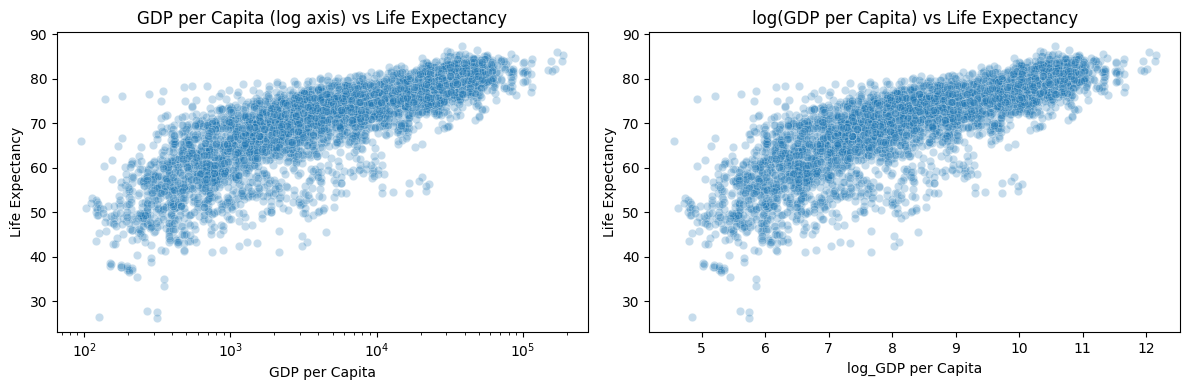

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_fe = df_model.copy()

# correlation comparison
if "GDP per Capita" in df_fe.columns and "log_GDP_per_Capita" in df_fe.columns:
    corr_raw = df_fe[["GDP per Capita", target_col]].corr().iloc[0,1]
    corr_log = df_fe[["log_GDP_per_Capita", target_col]].corr().iloc[0,1]
    print(f"Corr(LifeExp, GDP per Capita)     = {corr_raw:.3f}")
    print(f"Corr(LifeExp, log_GDP_per_Capita) = {corr_log:.3f}")

# scatterplots
plot_df = df_fe.sample(min(5000, len(df_fe)), random_state=42)

fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.scatterplot(data=plot_df, x="GDP per Capita", y=target_col, alpha=0.25, ax=ax[0])
ax[0].set_xscale("log")
ax[0].set_title("GDP per Capita (log axis) vs Life Expectancy")

sns.scatterplot(data=plot_df, x="log_GDP per Capita", y=target_col, alpha=0.25, ax=ax[1])
ax[1].set_title("log(GDP per Capita) vs Life Expectancy")

plt.tight_layout()
plt.show()


The plots themself was not that clear so I want to explore how much does new log based feature explain dataset

In [8]:
import statsmodels.api as sm
import numpy as np

# detect log GDP column safely
log_gdp_col = next(
    (c for c in ["log_GDP_per_Capita", "log_GDP per Capita"] if c in df_fe.columns),
    None
)

if log_gdp_col is None:
    raise ValueError("No log GDP column found.")

tmp = df_fe[["GDP per Capita", log_gdp_col, target_col]].dropna()

X_raw = sm.add_constant(tmp["GDP per Capita"])
X_log = sm.add_constant(tmp[log_gdp_col])

m_raw = sm.OLS(tmp[target_col], X_raw).fit()
m_log = sm.OLS(tmp[target_col], X_log).fit()

print("Raw GDP model R²:", m_raw.rsquared)
print("Log GDP model R²:", m_log.rsquared)


Raw GDP model R²: 0.30052901338294824
Log GDP model R²: 0.6365473143813648


,Life Expectancy
Infant Mortality Rate,-0.911046
Maternal Mortality Ratio,-0.807150
Life Expectancy,1.000000


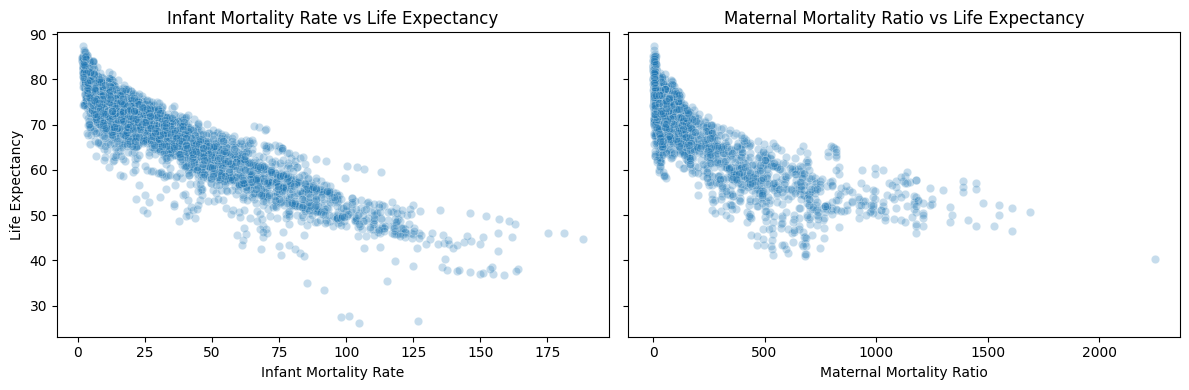

In [9]:
# Mortality variables vs Life Expectancy (side-by-side)
mortality_vars = [
    c for c in ["Infant Mortality Rate", "Maternal Mortality Ratio"]
    if c in df_fe.columns
]

# Correlation table (quantitative check)
display(
    df_fe[mortality_vars + [target_col]]
    .corr()[target_col]
    .sort_values()
)

# Sample for plotting
plot_df = df_fe.sample(min(5000, len(df_fe)), random_state=42)

fig, axes = plt.subplots(1, len(mortality_vars), figsize=(12,4), sharey=True)

for ax, v in zip(axes, mortality_vars):
    sns.scatterplot(
        data=plot_df,
        x=v,
        y=target_col,
        alpha=0.25,
        ax=ax
    )
    ax.set_title(f"{v} vs Life Expectancy")
    ax.set_xlabel(v)

axes[0].set_ylabel("Life Expectancy")

plt.tight_layout()
plt.show()

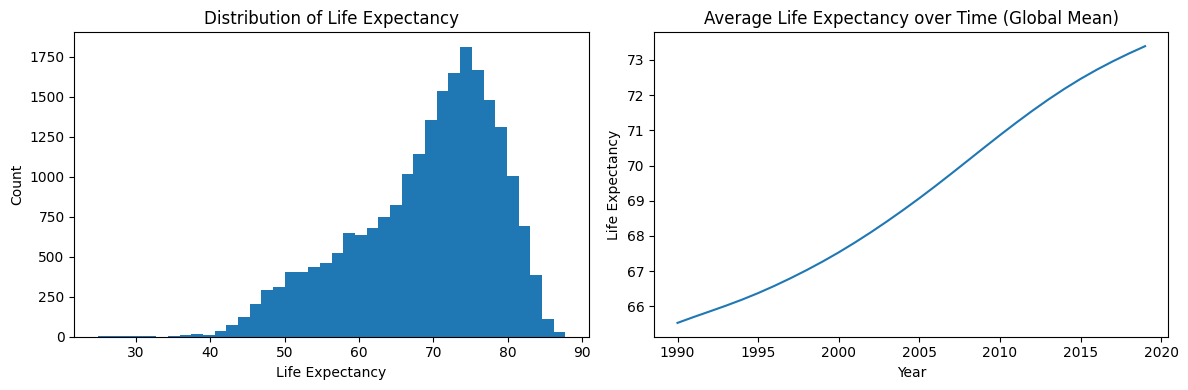

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Life Expectancy distribution
axes[0].hist(df["Life Expectancy"], bins=40)
axes[0].set_xlabel("Life Expectancy")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Life Expectancy")

# Global time trend
if "Year" in df_fe.columns:
    df_fe.groupby("Year")[target_col].mean().plot(ax=axes[1])
    axes[1].set_title("Average Life Expectancy over Time (Global Mean)")
    axes[1].set_ylabel("Life Expectancy")

plt.tight_layout()
plt.show()


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
const,74.313999,0.379291,195.928719,0.000000e+00,73.570511,75.057487
Infant Mortality Rate,-0.240271,0.001841,-130.543143,0.000000e+00,-0.243879,-0.236663
animal_to_plant_protein_ratio,-1.180215,0.343679,-3.434062,5.970453e-04,-1.853897,-0.506534
Diet Calories Animal Protein,0.025555,0.002255,11.334538,1.346705e-29,0.021136,0.029975
Diet Calories Plant Protein,-0.002248,0.001893,-1.187243,2.351604e-01,-0.005959,0.001463


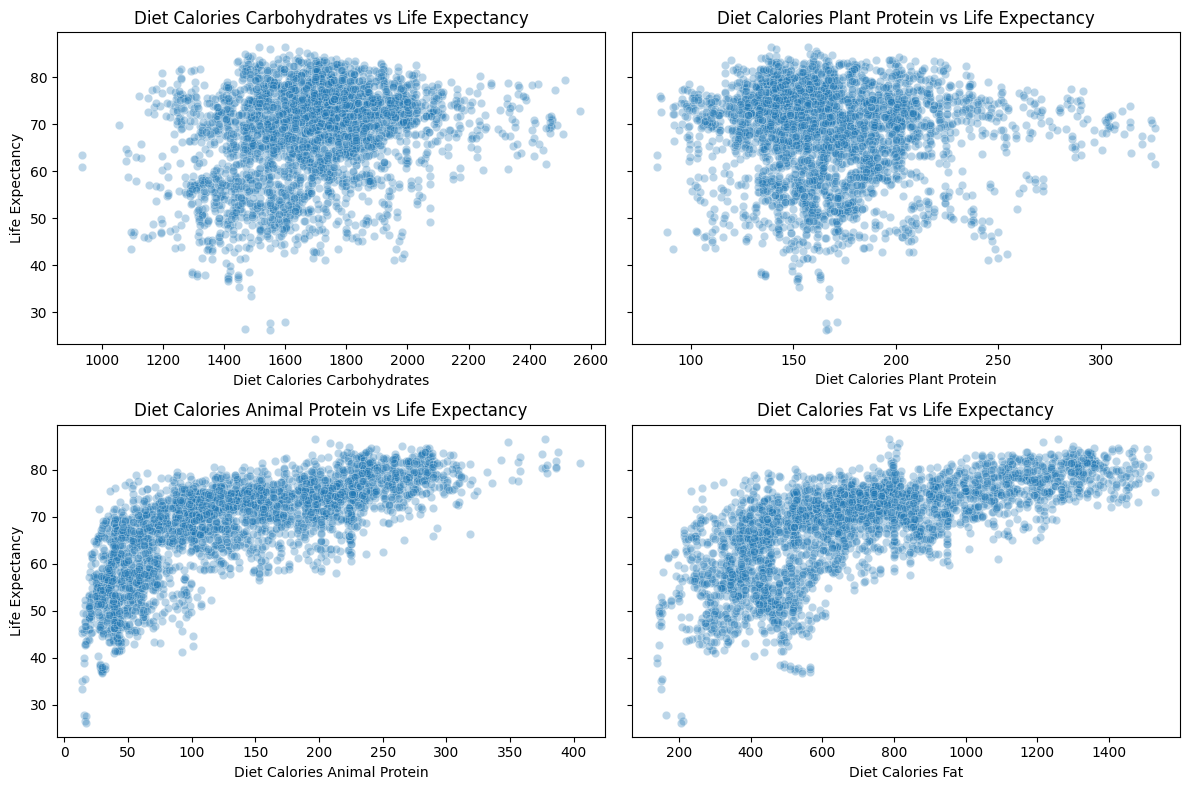

In [ ]:
import statsmodels.api as sm

nutri_cols = [
    c for c in [
        "animal_to_plant_protein_ratio",
        "Diet Calories Animal Protein",
        "Diet Calories Plant Protein"
    ]
    if c in df_fe.columns
]

controls = [
    c for c in ["log_GDP_per_Capita", "Infant Mortality Rate"]
    if c in df_fe.columns
]

tmp = df_fe[nutri_cols + controls + [target_col]].dropna()

X = sm.add_constant(tmp[controls + nutri_cols])
y = tmp[target_col]
m = sm.OLS(y, X).fit()

display(m.summary2().tables[1])


# --- Nutrition scatterplots (2x2 layout) ---
nutrition_vars = [
    c for c in [
        "Diet Calories Carbohydrates",
        "Diet Calories Plant Protein",
        "Diet Calories Animal Protein",
        "Diet Calories Fat",
    ]
    if c in df_fe.columns
]

plot_df = df_fe.sample(min(5000, len(df_fe)), random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(12,8), sharey=True)
axes = axes.flatten()

for ax, var in zip(axes, nutrition_vars):
    sns.scatterplot(
        data=plot_df,
        x=var,
        y=target_col,
        alpha=0.30,
        ax=ax
    )
    ax.set_title(f"{var} vs Life Expectancy")
    ax.set_xlabel(var)

for ax in axes[len(nutrition_vars):]:
    ax.axis("off")

axes[0].set_ylabel("Life Expectancy")
axes[2].set_ylabel("Life Expectancy")

plt.tight_layout()
plt.show()


Correlation analysis:

I compute correlations only on numeric columns (correlation ≠ causation).

Very strong correlations are expected here because development indicators move together:

positive: UHC, water, sanitation, log GDP, clean fuel

negative: infant mortality, maternal mortality, dependency ratio

If many features are highly correlated, linear models can still work, but coefficients may be unstable → that’s why I also compare tree/boosting models and add PCA/ICA.

In [12]:
# --- Final numeric features used in the report ---
final_numeric_features = [
    # target
    target_col,

    # economic
    "log_GDP per Capita",

    # mortality
    "Infant Mortality Rate",
    "Under 5 Mortality Rate",
    "Neonatal Mortality Rate",
    "Death Rate",
    "Maternal Mortality Ratio",

    # demographics
    "% Population Aged 0-14",
    "% Population Aged 15-64",
    "% Population Aged 65+",
    "dependency_ratio",
    "Birth Rate",

    # infrastructure
    "Basic Drinking Water Services",
    "Basic Sanization Services Total",
    "Clean Fuel and Technology",

    # nutrition
    "Diet Calories Animal Protein",
    "Diet Calories Plant Protein",
    "Diet Calories Fat",
    "Diet Calories Carbohydrates",
    "animal_to_plant_protein_ratio",


    # safety / stability
    "Homicide Rate",
    "Conflict and Terrorism Deaths",
]

# keep only columns that actually exist
final_numeric_features = [c for c in final_numeric_features if c in df_fe.columns]


In [13]:
corr_target = (
    df_fe[final_numeric_features]
    .corr()[target_col]
    .drop(target_col)
    .sort_values(ascending=False)
)

print("Top positive correlations with Life Expectancy:")
display(corr_target.head(10))

print("Top negative correlations with Life Expectancy:")
display(corr_target.tail(10))


Top positive correlations with Life Expectancy:


,Life Expectancy
Basic Sanization Services Total,0.821512
Basic Drinking Water Services,0.803047
log_GDP per Capita,0.797839
Clean Fuel and Technology,0.770879
% Population Aged 15-64,0.743965
Diet Calories Animal Protein,0.731341
Diet Calories Fat,0.701940
% Population Aged 65+,0.675321
animal_to_plant_protein_ratio,0.660313
Diet Calories Carbohydrates,0.256763


Top negative correlations with Life Expectancy:


,Life Expectancy
Conflict and Terrorism Deaths,-0.087191
Homicide Rate,-0.116940
Death Rate,-0.641945
dependency_ratio,-0.769346
Maternal Mortality Ratio,-0.807150
% Population Aged 0-14,-0.811119
Birth Rate,-0.847720
Neonatal Mortality Rate,-0.854631
Under 5 Mortality Rate,-0.902902
Infant Mortality Rate,-0.911046


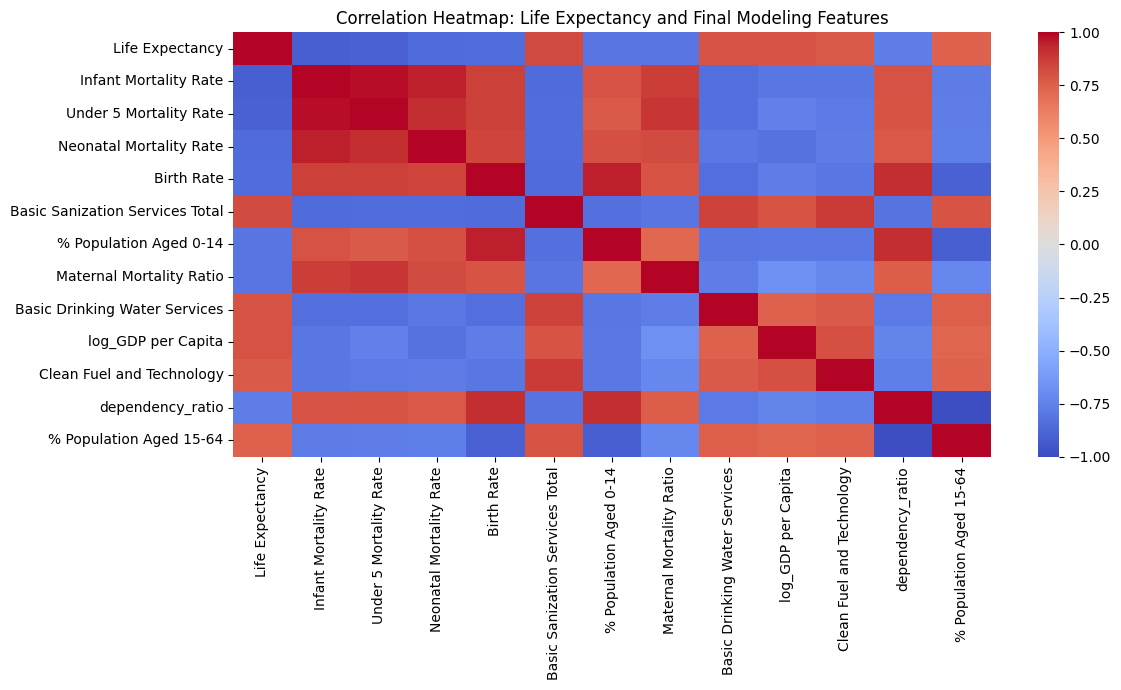

In [14]:
# select top features by absolute correlation (from final feature set)
top_feats = (
    corr_target.abs()
    .sort_values(ascending=False)
    .head(12)
    .index
    .tolist()
)

plt.figure(figsize=(12,7))
sns.heatmap(
    df_fe[[target_col] + top_feats].corr(),
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot=False
)
plt.title("Correlation Heatmap: Life Expectancy and Final Modeling Features")
plt.tight_layout()
plt.show()


In [15]:
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

X = df_fe[final_features].copy()
y = df_fe[target_col].copy()

num_feats = X.select_dtypes(include=[np.number]).columns.tolist()
cat_feats = X.select_dtypes(include=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_feats),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_feats)
    ],
    sparse_threshold=0.0  # force dense output overall
)

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001, max_iter=10000),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
}

def adjusted_r2(r2, n, p):
    # adjusted R2 = 1 - (1-R2)*(n-1)/(n-p-1)
    # p should be number of model inputs after preprocessing; I approximate using transformed feature count.
    if n <= p + 1:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

def evaluate_model(pipe, X_tr, X_te, y_tr, y_te):
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)

    mse = mean_squared_error(y_te, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_te, pred)

    # approximate p using transformed feature dimension
    Xt = pipe.named_steps["prep"].transform(X_tr)
    p = Xt.shape[1]
    n = len(y_te)

    return {
        "MAE": mean_absolute_error(y_te, pred),
        "RMSE": rmse,
        "R2": r2,
        "Adj_R2(approx)": adjusted_r2(r2, n=n, p=p)
    }


## Model evaluation strategy (three train/test splits)

Because the dataset contains **repeated observations by Country and Year**, a single random train/test split can look “too good” by letting the model learn country-specific patterns that also appear in the test set.  
To check how well the model *really* generalizes, I evaluate each model under three increasingly strict split settings:

### 1) Random split (easiest / optimistic)
- Train and test are a random mix of **countries and years**.
- The model often sees the *same country* in both train and test (just in different years).
- This setting is common in ML, but it can **overestimate performance** for panel data.

### 2) Time split (future generalization)
- Train on years **≤ 2012**, test on years **> 2012**.
- Tests whether relationships learned from earlier years still hold for **later years**.
- This is important when the goal is forecasting or policy analysis over time.

### 3) Country split (hardest / strongest generalization)
- Split by **Country** (GroupShuffleSplit): countries in the test set are **never seen during training**.
- This is the most realistic test if the goal is to predict life expectancy for **new countries** or countries with limited historical data.

### Metrics reported
- **MAE** (years): average absolute error in life expectancy.
- **RMSE** (years): penalizes large errors more heavily than MAE.
- **R²**: fraction of variance explained.
- **Adjusted R² (approx.)**: adjusted for number of predictors (approximate because preprocessing changes the effective feature count).


In [16]:
results = []

# -----------------------
# 1) RANDOM SPLIT
# -----------------------
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    m = evaluate_model(pipe, X_tr, X_te, y_tr, y_te)
    m.update({"split": "random", "model": name})
    results.append(m)

# -----------------------
# 2) TIME SPLIT
# -----------------------
if "Year" in df_fe.columns:
    cutoff = 2012
    tr_mask = df_fe["Year"] <= cutoff
    te_mask = df_fe["Year"] > cutoff

    # Only evaluate if we have both sides non-empty
    if tr_mask.sum() > 0 and te_mask.sum() > 0:
        for name, model in models.items():
            pipe = Pipeline([("prep", preprocessor), ("model", model)])
            m = evaluate_model(pipe, X.loc[tr_mask], X.loc[te_mask], y.loc[tr_mask], y.loc[te_mask])
            m.update({"split": "time", "model": name})
            results.append(m)

# -----------------------
# 3) COUNTRY SPLIT
# -----------------------
if "Country" in df_fe.columns:
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=df_fe["Country"]))

    for name, model in models.items():
        pipe = Pipeline([("prep", preprocessor), ("model", model)])
        m = evaluate_model(pipe, X.iloc[train_idx], X.iloc[test_idx], y.iloc[train_idx], y.iloc[test_idx])
        m.update({"split": "country", "model": name})
        results.append(m)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["split", "MAE"]).reset_index(drop=True)

display(results_df)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.146e+03, tolerance: 1.439e+02
  model = cd_fast.enet_coordinate_descent(


,MAE,RMSE,R2,Adj_R2(approx),split,model
0,1.428006,2.030990,0.940575,0.937189,country,HistGradientBoosting
1,1.530636,2.094625,0.936793,0.933191,country,RandomForest
2,2.220983,3.479835,0.825551,0.815609,country,Lasso
3,2.749178,3.811738,0.790687,0.778757,country,Ridge
4,3.558637,4.475249,0.711474,0.695030,country,Linear
5,0.405976,0.620421,0.995808,0.995502,random,RandomForest
6,0.664088,0.913974,0.990902,0.990239,random,HistGradientBoosting
7,0.900761,1.257597,0.982776,0.981520,random,Linear
8,0.913042,1.275680,0.982277,0.980985,random,Ridge
9,0.963069,1.349933,0.980153,0.978707,random,Lasso


1) Random split is extremely optimistic

Random split results are very high.

That’s because the model sees the same countries in train and test, and many indicators are stable within a country.

2) Time split is harder (still good)

R² drops to around 0.88–0.93 depending on model.

This is more realistic:  forecasting future years using past patterns.

3) Country split is the real test

This is the key: performance drops a lot because the model must generalize to new countries.

RandomForest is slightly worse under country split.

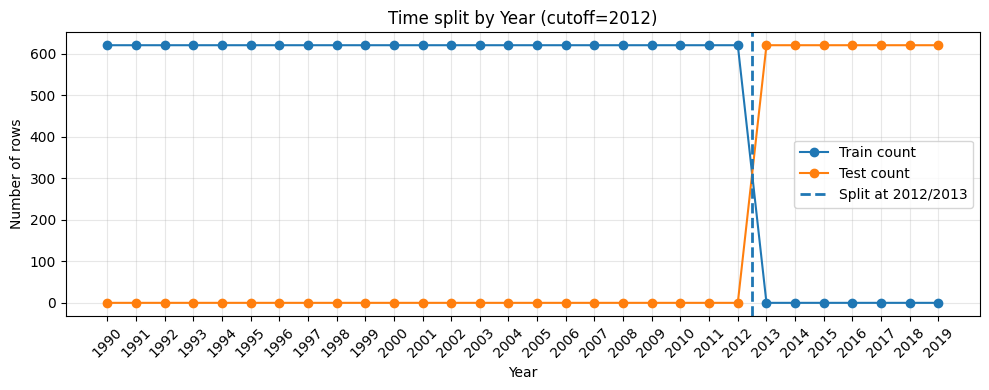

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_time_split(df_fe, cutoff=2012, year_col="Year"):
    if year_col not in df_fe.columns:
        print(f"'{year_col}' not found.")
        return

    d = df_fe[[year_col]].dropna().copy()
    d[year_col] = pd.to_numeric(d[year_col], errors="coerce")
    d = d.dropna()

    # counts by year for train/test
    d["split"] = np.where(d[year_col] <= cutoff, "train (<= cutoff)", "test (> cutoff)")
    counts = d.groupby([year_col, "split"]).size().unstack(fill_value=0)

    # Ensure both columns exist even if one side is empty
    for col in ["train (<= cutoff)", "test (> cutoff)"]:
        if col not in counts.columns:
            counts[col] = 0

    years = counts.index.values
    train_counts = counts["train (<= cutoff)"].values
    test_counts  = counts["test (> cutoff)"].values

    plt.figure(figsize=(10, 4))
    plt.plot(years, train_counts, marker="o", label="Train count")
    plt.plot(years, test_counts, marker="o", label="Test count")

    plt.axvline(cutoff + 0.5, linestyle="--", linewidth=2, label=f"Split at {cutoff}/{cutoff+1}")
    plt.title(f"Time split by {year_col} (cutoff={cutoff})")
    plt.xlabel(year_col)
    plt.ylabel("Number of rows")
    plt.xticks(years, rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# usage
plot_time_split(df_fe, cutoff=2012, year_col="Year")

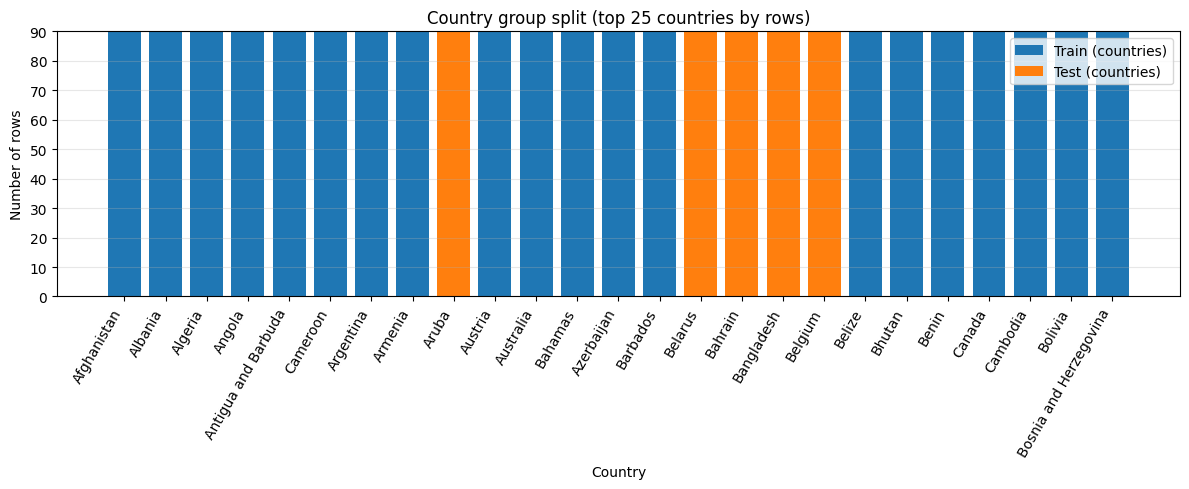

Unique countries in train: 183
Unique countries in test : 46
Overlap (should be 0): 0


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

def plot_country_split(df_fe, X, y, country_col="Country", test_size=0.2, random_state=42, top_n=25):
    if country_col not in df_fe.columns:
        print(f"'{country_col}' not found.")
        return

    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(X, y, groups=df_fe[country_col]))

    train_countries = set(df_fe.iloc[train_idx][country_col].dropna().unique())
    test_countries  = set(df_fe.iloc[test_idx][country_col].dropna().unique())

    d = df_fe[[country_col]].copy()
    d["split"] = np.where(d[country_col].isin(train_countries), "train", "test")

    # counts per country (stacked)
    ct = d.groupby([country_col, "split"]).size().unstack(fill_value=0)

    # keep it readable: show top_n by total rows
    ct["total"] = ct.sum(axis=1)
    ct = ct.sort_values("total", ascending=False).head(top_n)
    train_counts = ct.get("train", pd.Series(0, index=ct.index))
    test_counts  = ct.get("test",  pd.Series(0, index=ct.index))

    plt.figure(figsize=(12, 5))
    plt.bar(ct.index.astype(str), train_counts.values, label="Train (countries)")
    plt.bar(ct.index.astype(str), test_counts.values, bottom=train_counts.values, label="Test (countries)")
    plt.title(f"Country group split (top {top_n} countries by rows)")
    plt.xlabel("Country")
    plt.ylabel("Number of rows")
    plt.xticks(rotation=60, ha="right")
    plt.grid(True, axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # sanity check summary
    print(f"Unique countries in train: {len(train_countries)}")
    print(f"Unique countries in test : {len(test_countries)}")
    print(f"Overlap (should be 0): {len(train_countries & test_countries)}")

# usage
plot_country_split(df_fe, X, y, country_col="Country", test_size=0.2, random_state=42, top_n=25)


In [17]:
# Pretty display (rounded) + best model per split
pretty = results_df.copy()
pretty["MAE"] = pretty["MAE"].round(3)
pretty["RMSE"] = pretty["RMSE"].round(3)
pretty["R2"] = pretty["R2"].round(3)
pretty["Adj_R2(approx)"] = pretty["Adj_R2(approx)"].round(3)

display(pretty)

print("\nBest model per split (lowest MAE):")
display(pretty.sort_values(["split", "MAE"]).groupby("split").head(1))


,MAE,RMSE,R2,Adj_R2(approx),split,model
0,1.428,2.031,0.941,0.937,country,HistGradientBoosting
1,1.531,2.095,0.937,0.933,country,RandomForest
2,2.221,3.480,0.826,0.816,country,Lasso
3,2.749,3.812,0.791,0.779,country,Ridge
4,3.559,4.475,0.711,0.695,country,Linear
5,0.406,0.620,0.996,0.996,random,RandomForest
6,0.664,0.914,0.991,0.990,random,HistGradientBoosting
7,0.901,1.258,0.983,0.982,random,Linear
8,0.913,1.276,0.982,0.981,random,Ridge
9,0.963,1.350,0.980,0.979,random,Lasso



Best model per split (lowest MAE):


,MAE,RMSE,R2,Adj_R2(approx),split,model
0,1.428,2.031,0.941,0.937,country,HistGradientBoosting
5,0.406,0.620,0.996,0.996,random,RandomForest
10,1.160,1.681,0.956,0.953,time,HistGradientBoosting


In [18]:
from sklearn.base import clone

def run_one_split_compare(include_country=True):
    feat_use = final_features.copy()
    if not include_country and "Country" in feat_use:
        feat_use.remove("Country")

    X2 = df_fe[feat_use].copy()
    y2 = df_fe[target_col].copy()

    num2 = X2.select_dtypes(include=[np.number]).columns.tolist()
    cat2 = X2.select_dtypes(include=["object"]).columns.tolist()

    prep2 = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), num2),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]), cat2)
        ],
        sparse_threshold=0.0
    )

    Xtr, Xte, ytr, yte = train_test_split(X2, y2, test_size=0.2, random_state=42)

    rows = []
    for name, model in models.items():
        pipe = Pipeline([("prep", prep2), ("model", clone(model))])
        m = evaluate_model(pipe, Xtr, Xte, ytr, yte)
        m.update({"setting": "with_country" if include_country else "no_country", "model": name})
        rows.append(m)
    return pd.DataFrame(rows)

comp_with = run_one_split_compare(include_country=True)
comp_without = run_one_split_compare(include_country=False)

comp = pd.concat([comp_with, comp_without], axis=0)
comp["MAE"] = comp["MAE"].round(3)
comp["RMSE"] = comp["RMSE"].round(3)
comp["R2"] = comp["R2"].round(3)
comp["Adj_R2(approx)"] = comp["Adj_R2(approx)"].round(3)

display(comp.sort_values(["setting", "MAE"]))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.146e+03, tolerance: 1.439e+02
  model = cd_fast.enet_coordinate_descent(


,MAE,RMSE,R2,Adj_R2(approx),setting,model
4,0.632,1.390,0.979,0.979,no_country,RandomForest
3,0.837,1.433,0.978,0.977,no_country,HistGradientBoosting
0,1.673,2.588,0.927,0.927,no_country,Linear
2,1.677,2.594,0.927,0.926,no_country,Lasso
1,1.693,2.611,0.926,0.925,no_country,Ridge
4,0.406,0.620,0.996,0.996,with_country,RandomForest
3,0.664,0.914,0.991,0.990,with_country,HistGradientBoosting
0,0.901,1.258,0.983,0.982,with_country,Linear
1,0.913,1.276,0.982,0.981,with_country,Ridge
2,0.963,1.350,0.980,0.979,with_country,Lasso


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# --- Find the log GDP column (supports both naming styles) ---
candidates = ["log_GDP_per_Capita", "log_GDP per Capita", "log_GDP_per_Capita"]
log_gdp_col = next((c for c in candidates if c in df_fe.columns), None)

if log_gdp_col is None:
    # If it's missing, create it safely from GDP per Capita
    if "GDP per Capita" not in df_fe.columns:
        raise ValueError("No GDP per Capita column found to create log GDP.")
    df_fe = df_fe.copy()
    df_fe["log_GDP per Capita"] = np.log(df_fe["GDP per Capita"].where(df_fe["GDP per Capita"] > 0))
    log_gdp_col = "log_GDP per Capita"

print("Using log GDP column:", log_gdp_col)

# --- Choose available columns ---
base_cols = [log_gdp_col]

infra_cols = [c for c in [
    "Basic Drinking Water Services",
    "Basic Sanization Services Total",
    "Clean Fuel and Technology",
    "Universal Heath Care Coverage"
] if c in df_fe.columns]

# --- Build dataset ---
tmp = df_fe[base_cols + infra_cols + [target_col]].dropna()

X_A = sm.add_constant(tmp[base_cols])
y_A = tmp[target_col]
mA = sm.OLS(y_A, X_A).fit()

X_B = sm.add_constant(tmp[base_cols + infra_cols])
y_B = tmp[target_col]
mB = sm.OLS(y_B, X_B).fit()

print("\nModel A (LifeExp ~ logGDP)")
print(mA.params)

print("\nModel B (LifeExp ~ logGDP + infrastructure)")
print(mB.params)

# --- Robust coefficient access (no hard-coded name) ---
coef_A = mA.params.get(log_gdp_col, np.nan)
coef_B = mB.params.get(log_gdp_col, np.nan)

print("\nlogGDP coefficient shrinkage:")
print("A:", coef_A)
print("B:", coef_B)


Using log GDP column: log_GDP per Capita

Model A (LifeExp ~ logGDP)
const                 31.881568
log_GDP per Capita     4.644422
dtype: float64

Model B (LifeExp ~ logGDP + infrastructure)
const                              38.747813
log_GDP per Capita                  1.403691
Basic Drinking Water Services       0.094293
Basic Sanization Services Total     0.036696
Clean Fuel and Technology          -0.006781
Universal Heath Care Coverage       0.175638
dtype: float64

logGDP coefficient shrinkage:
A: 4.644421534701273
B: 1.4036907482506726


In [20]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# numeric-only for PCA/ICA
X_num = df_fe[final_features].select_dtypes(include=[np.number]).copy()
y_all = df_fe[target_col].copy()

print("Numeric feature matrix shape:", X_num.shape)

# Impute + scale
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_num_imp = imputer.fit_transform(X_num)
X_num_scaled = scaler.fit_transform(X_num_imp)

X_num_scaled = pd.DataFrame(X_num_scaled, columns=X_num.columns, index=df_fe.index)
display(X_num_scaled.head())


Numeric feature matrix shape: (18630, 21)


,Year,log_GDP per Capita,Infant Mortality Rate,Under 5 Mortality Rate,Neonatal Mortality Rate,Death Rate,Birth Rate,% Population Aged 0-14,% Population Aged 15-64,% Population Aged 65+,dependency_ratio,Basic Drinking Water Services,Basic Sanization Services Total,Clean Fuel and Technology,Diet Calories Animal Protein,Diet Calories Plant Protein,Diet Calories Fat,Diet Calories Carbohydrates,animal_to_plant_protein_ratio,Homicide Rate,Conflict and Terrorism Deaths
0,-1.675247,-0.024332,3.155098,2.847227,4.244937,1.843532,2.326003,1.686702,-1.838636,-0.967365,2.067201,0.275228,0.322435,0.377172,-0.939432,0.988016,-1.007907,-0.384613,-0.987642,0.602247,0.162415
1,-1.675247,-0.024332,2.937804,2.750433,4.244937,1.843532,2.326003,1.659907,-1.821320,-0.935697,2.041706,0.275228,0.322435,0.377172,-0.939432,0.988016,-1.007907,-0.384613,-0.987642,0.602247,0.162415
2,-1.675247,-0.024332,3.358372,2.937708,4.244937,1.843532,2.326003,1.712329,-1.855201,-0.997648,2.091700,0.275228,0.322435,0.377172,-0.939432,0.988016,-1.007907,-0.384613,-0.987642,0.602247,0.162415
3,-1.559712,-0.024332,3.028927,2.720974,4.139709,1.714309,2.315245,1.677796,-1.826479,-0.965401,2.049290,0.275228,0.322435,0.377172,-0.983156,0.210066,-1.265706,-1.354844,-0.922484,0.798778,0.461181
4,-1.559712,-0.024332,2.815139,2.624180,4.139709,1.714309,2.315245,1.654269,-1.813549,-0.934555,2.030304,0.275228,0.322435,0.377172,-0.983156,0.210066,-1.265706,-1.354844,-0.922484,0.798778,0.461181


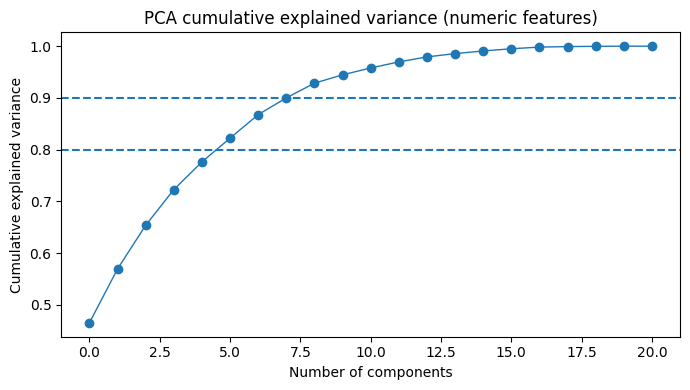

Components for 80% variance: 6
Components for 90% variance: 9


In [21]:
from sklearn.decomposition import PCA

pca_full = PCA(random_state=42)
pca_full.fit(X_num_scaled)

explained = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure(figsize=(7,4))
plt.plot(cum_explained, marker="o", linewidth=1)
plt.axhline(0.80, linestyle="--")
plt.axhline(0.90, linestyle="--")
plt.title("PCA cumulative explained variance (numeric features)")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.tight_layout()
plt.show()

k90 = int(np.argmax(cum_explained >= 0.90) + 1)
k80 = int(np.argmax(cum_explained >= 0.80) + 1)

print(f"Components for 80% variance: {k80}")
print(f"Components for 90% variance: {k90}")


In [ ]:
k = min(k90, 7)

pca = PCA(n_components=k, random_state=42)
X_pca = pca.fit_transform(X_num_scaled)

loadings = pd.DataFrame(
    pca.components_.T,
    index=X_num.columns,
    columns=[f"PC{i+1}" for i in range(k)]
)

def show_top_loadings(component, top_n=12):
    s = loadings[component].sort_values(key=np.abs, ascending=False).head(top_n)
    display(s)

print("Top loadings for PC1:")
show_top_loadings("PC1")

print("Top loadings for PC2:")
show_top_loadings("PC2")

print("Top loadings for PC3:")
show_top_loadings("PC3")


Top loadings for PC1:


,PC1
Birth Rate,0.296645
% Population Aged 0-14,0.293032
Neonatal Mortality Rate,0.287157
dependency_ratio,0.282019
% Population Aged 15-64,-0.277375
Infant Mortality Rate,0.273234
Under 5 Mortality Rate,0.266464
log_GDP per Capita,-0.264511
Diet Calories Animal Protein,-0.240116
% Population Aged 65+,-0.226821


Top loadings for PC2:


,PC2
Diet Calories Plant Protein,0.478771
Diet Calories Carbohydrates,0.466056
animal_to_plant_protein_ratio,-0.375389
Year,0.287533
Diet Calories Animal Protein,-0.254090
Diet Calories Fat,-0.206947
Death Rate,-0.198721
Clean Fuel and Technology,-0.167593
% Population Aged 15-64,0.156836
dependency_ratio,-0.155086


Top loadings for PC3:


,PC3
Clean Fuel and Technology,0.437130
Basic Sanization Services Total,0.433575
Basic Drinking Water Services,0.409576
Year,-0.346642
Diet Calories Plant Protein,0.276723
animal_to_plant_protein_ratio,-0.227726
Diet Calories Carbohydrates,0.206030
Death Rate,0.191443
Diet Calories Animal Protein,-0.161229
Under 5 Mortality Rate,0.159070


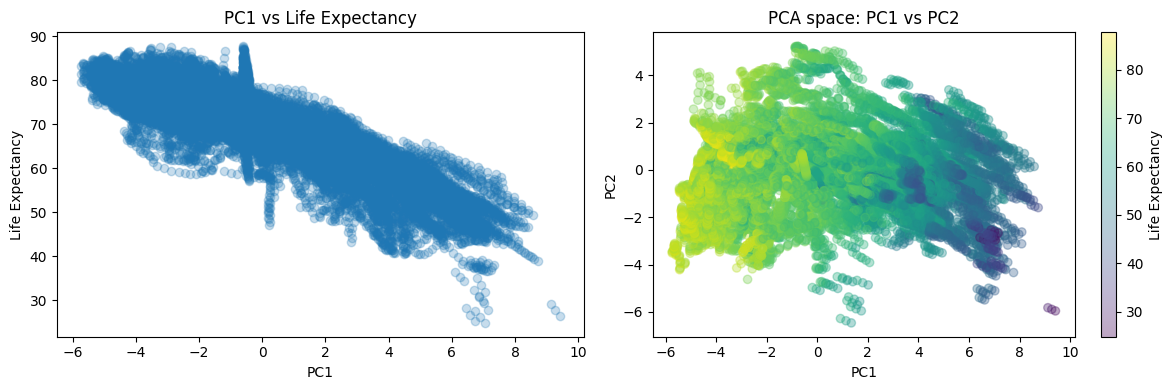

In [23]:
pca_df = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(k)], index=df_fe.index)
pca_df[target_col] = y_all.values

fig, axes = plt.subplots(1, 2, figsize=(12,4))

# PC1 vs Life Expectancy
axes[0].scatter(pca_df["PC1"], pca_df[target_col], alpha=0.25)
axes[0].set_title("PC1 vs Life Expectancy")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("Life Expectancy")

# PC1 vs PC2 colored by Life Expectancy
sc = axes[1].scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df[target_col],
    alpha=0.35
)
axes[1].set_title("PCA space: PC1 vs PC2")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.colorbar(sc, ax=axes[1], label="Life Expectancy")

plt.tight_layout()
plt.show()



Convert PCA scores to DataFrame

Country-level PCA matrix shape: (229, 7)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
Country,,,,,,,
Afghanistan,5.692176,-0.751819,-0.185678,0.020213,0.391363,0.566315,-0.040320
Albania,-1.407680,0.760114,0.212081,0.166730,-0.368312,0.069779,-0.108504
Algeria,0.004150,2.192291,1.489176,-0.077275,-1.116624,0.224214,-0.675194
Andorra,-1.917456,0.341905,0.351599,-1.111528,-0.157820,-0.145299,-0.869200
Angola,5.824466,-2.022680,-0.241715,0.640351,0.907189,-0.612110,-0.343969


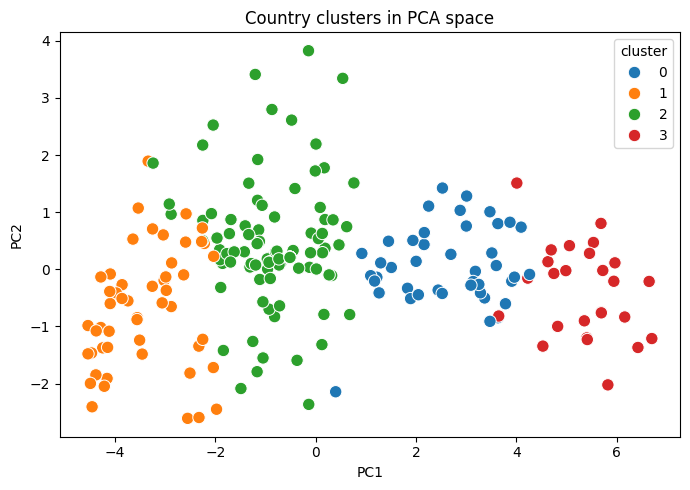

In [24]:
pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(k)],
    index=df_fe.index
)

pca_df["Country"] = df_fe["Country"]

country_pca = (
    pca_df
    .groupby("Country")
    .mean()
)

print("Country-level PCA matrix shape:", country_pca.shape)
display(country_pca.head())

from sklearn.cluster import KMeans

k_clusters = 4  # 3–5 is reasonable, 4 usually works well

kmeans = KMeans(
    n_clusters=k_clusters,
    random_state=42,
    n_init=10
)

country_pca["cluster"] = kmeans.fit_predict(country_pca)
country_pca["cluster"].value_counts()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=country_pca,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    s=80
)
plt.title("Country clusters in PCA space")
plt.tight_layout()
plt.show()



In [25]:
log_gdp_col = next(
    (c for c in ["log_GDP_per_Capita", "log_GDP per Capita"] if c in df_fe.columns),
    None
)
if log_gdp_col is None:
    raise ValueError("No log GDP column found. Create it first.")

country_profile = (
    df_fe
    .groupby("Country")[[
        "Life Expectancy",
        log_gdp_col,
        "Infant Mortality Rate",
        "dependency_ratio",
        "Diet Calories Animal Protein"
    ]]
    .mean()
    .join(country_pca["cluster"])
    .groupby("cluster")
    .mean()
)

display(country_profile)


,Life Expectancy,log_GDP per Capita,Infant Mortality Rate,dependency_ratio,Diet Calories Animal Protein
cluster,,,,,
0,61.913462,7.002877,49.081542,0.786728,72.419009
1,76.967210,9.762996,6.622427,0.495465,230.539888
2,73.347083,8.668154,20.468193,0.559766,129.198683
3,53.115435,6.212380,86.322556,0.932781,40.966111


In [26]:
# country_pca is indexed by country names, so just convert index -> column
country_pca = country_pca.reset_index()

# rename safely
if "index" in country_pca.columns:
    country_pca = country_pca.rename(columns={"index": "Country"})

country_pca.head()

,Country,PC1,PC2,PC3,PC4,PC5,PC6,PC7,cluster
0,Afghanistan,5.692176,-0.751819,-0.185678,0.020213,0.391363,0.566315,-0.040320,3
1,Albania,-1.407680,0.760114,0.212081,0.166730,-0.368312,0.069779,-0.108504,2
2,Algeria,0.004150,2.192291,1.489176,-0.077275,-1.116624,0.224214,-0.675194,2
3,Andorra,-1.917456,0.341905,0.351599,-1.111528,-0.157820,-0.145299,-0.869200,2
4,Angola,5.824466,-2.022680,-0.241715,0.640351,0.907189,-0.612110,-0.343969,3


In [27]:
for c in sorted(country_pca["cluster"].unique()):
    sample = country_pca.loc[country_pca["cluster"] == c, "Country"].head(8).tolist()
    print(f"Cluster {c} example countries:", sample)

Cluster 0 example countries: ['Bangladesh', 'Bhutan', 'Botswana', 'Cambodia', 'Cape Verde', 'Comoros', 'Congo', "Cote d'Ivoire"]
Cluster 1 example countries: ['Antigua and Barbuda', 'Argentina', 'Australia', 'Austria', 'Bahamas', 'Barbados', 'Belarus', 'Belgium']
Cluster 2 example countries: ['Albania', 'Algeria', 'Andorra', 'Anguilla', 'Armenia', 'Aruba', 'Australia & New Zealand', 'Azerbaijan']
Cluster 3 example countries: ['Afghanistan', 'Angola', 'Benin', 'Burkina Faso', 'Burundi', 'Cameroon', 'Chad', 'Democratic Republic of Congo']
